In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import UpROOT.io as io
import UpROOT.config as conf
import UpROOT.physics.delphes as ph
import UpROOT.plotting.delphes as pt
import UpROOT.pipelines.delphes as pl
import UpROOT.fitting.delphes as fi
import UpROOT.delphes_root as dr

In [ ]:
DATASET01 = 'mpmm_50k_10'

In [5]:
io.load_dataframe(
    branches=io.txt_data("mpmm"),
    dataset=DATASET01,
).head()

Ramas cargadas desde: C:\Users\mario\Documents\PF\MadGraph\analysis\mpmm.txt
Cantidad de ramas: 33
Archivo: MG5_pp_mpmm_50k_10GeV.root
Árbol seleccionado: Delphes
Archivo: MG5_pp_mpmm_50k_10GeV_2.root
Árbol seleccionado: Delphes
Total de eventos: 100,000 eventos


,Event/Event.CrossSection,Event/Event.CrossSectionError,Event/Event.Number,Event/Event.Weight,Jet/Jet.BTag,Jet/Jet.Charge,Jet/Jet.ChargedEnergyFraction,Jet/Jet.Constituents,Jet/Jet.Eta,Jet/Jet.Mass,...,Muon/Muon.IsolationVarRhoCorr,Muon/Muon.PT,Muon/Muon.Particle,Muon/Muon.Phi,Muon/Muon.SumPt,Muon/Muon.SumPtCharged,Muon/Muon.SumPtChargedPU,Muon/Muon.SumPtNeutral,Muon/Muon.T,Muon_size
0,[4.447943687438965],[55599.296875],[0],[32134.41015625],[],[],[],[],[],[],...,[0.0],[1.6846373081207275],[{'ref': 43}],[0.08056513965129852],[0.0],[0.0],[0.0],[0.0],[5.7438152012423416e-09],1
1,[8.89588737487793],[0.0],[1],[30397.369140625],[],[],[],[],[],[],...,"[0.0, 0.0]","[6.966477870941162, 0.7873199582099915]","[{'ref': 52}, {'ref': 51}]","[-0.534604012966156, 1.7801653146743774]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[1.0784368065230865e-08, 8.912818039163994e-09]",2
2,[13.343831062316895],[0.0],[2],[29585.318359375],[],[],[],[],[],[],...,"[0.0, 0.0]","[3.2190887928009033, 2.229984760284424]","[{'ref': 18}, {'ref': 19}]","[0.28717902302742004, -1.3845956325531006]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[8.056570521830508e-09, 1.0824569685041752e-08]",2
3,[17.79177474975586],[0.0],[3],[20467.740234375],[],[],[],[],[],[],...,[0.0],[1.104896903038025],[{'ref': 42}],[-1.3548110723495483],[0.0],[0.0],[0.0],[0.0],[1.0822165386059623e-08],1
4,[22.239717483520508],[0.0],[4],[29913.71484375],[],[],[],[],[],[],...,"[0.0, 0.0]","[3.5318753719329834, 1.3686586618423462]","[{'ref': 141}, {'ref': 142}]","[-1.3907488584518433, -2.9260826110839844]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[9.00399577119515e-09, 6.02169825114629e-09]",2


In [6]:
output = dr.convert_dataset(
    dataset=DATASET01,
    collections=('EFlowTrack', 'Electron', 'Event', 'Jet', 'Muon', 'Particle', 'Photon', 'ScalarHT', 'Track','Weight'),
    step_size='20 MB',
    object_registry=True,
    overwrite=True
)

Ramas internas de ROOT excluidas:
 - EFlowNeutralHadron/EFlowNeutralHadron.fBits
 - EFlowPhoton/EFlowPhoton.fBits
 - EFlowTrack/EFlowTrack.fBits
 - Electron/Electron.fBits
 - Event/Event.fBits
 - FatJet/FatJet.fBits
 - GenJet/GenJet.fBits
 - GenMissingET/GenMissingET.fBits
 - Jet/Jet.fBits
 - MissingET/MissingET.fBits
 - Muon/Muon.fBits
 - Particle/Particle.fBits
 - Photon/Photon.fBits
 - ScalarHT/ScalarHT.fBits
 - Tower/Tower.fBits
 - Track/Track.fBits
 - Weight/Weight.fBits

Archivo de entrada: C:\Users\mario\Documents\PF\data\MG5_pp_mpmm_50k_10GeV.root
Eventos: 50,000
Colecciones: EFlowTrack, Electron, Jet, Muon, Particle, Photon, ScalarHT, Track, Weight
 EFlowTracks: 54 ramas; bloques de 20 MB
 Electrons: 18 ramas; bloques de 20 MB
 Jets: 46 ramas; bloques de 20 MB
 Muons: 17 ramas; bloques de 20 MB
 Particles: 23 ramas; bloques de 20 MB
 Photons: 15 ramas; bloques de 20 MB
 ScalarHT: 2 ramas; bloques de 20 MB
 Tracks: 54 ramas; bloques de 20 MB
 Weights: 2 ramas; bloques de 20 MB


In [ ]:
PDATASET01 = 'mpmm_50k_10_p'

In [25]:
cut = '(Eta < 5.0) & (Eta > 2)'

In [26]:
df_events = io.load_dataframe(
    branches=None,
    dataset=PDATASET01,
    tree_path='Events',
)
df_events.head()

Archivo: mpmm_50k_10_pandas.root
Árbol seleccionado: Events
Total de eventos: 100,000 eventos


,source_file_id,event_id,source_entry,root_uid,event_number,ReadTime,ProcTime,ProcessID,MPI,event_weight,...,PDF2,n_EFlowTrack,n_Electron,n_Jet,n_Muon,n_Particle,n_Photon,n_ScalarHT,n_Track,n_Weight
0,0,0,0,0,0,0.022302,0.000923,9999,-1,32134.410156,...,0.0,7,0,0,1,178,0,1,7,292
1,0,1,1,0,1,0.000815,0.000825,9999,-1,30397.369141,...,0.0,5,0,0,2,224,0,1,5,292
2,0,2,2,0,2,0.000245,0.000188,9999,-1,29585.318359,...,0.0,3,0,0,2,94,0,1,3,292
3,0,3,3,0,3,0.000372,0.000294,9999,-1,20467.740234,...,0.0,4,0,0,1,160,0,1,4,292
4,0,4,4,0,4,0.000920,0.001535,9999,-1,29913.714844,...,0.0,10,0,0,2,447,0,1,10,292


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\delphes_event_multiplicities.png.


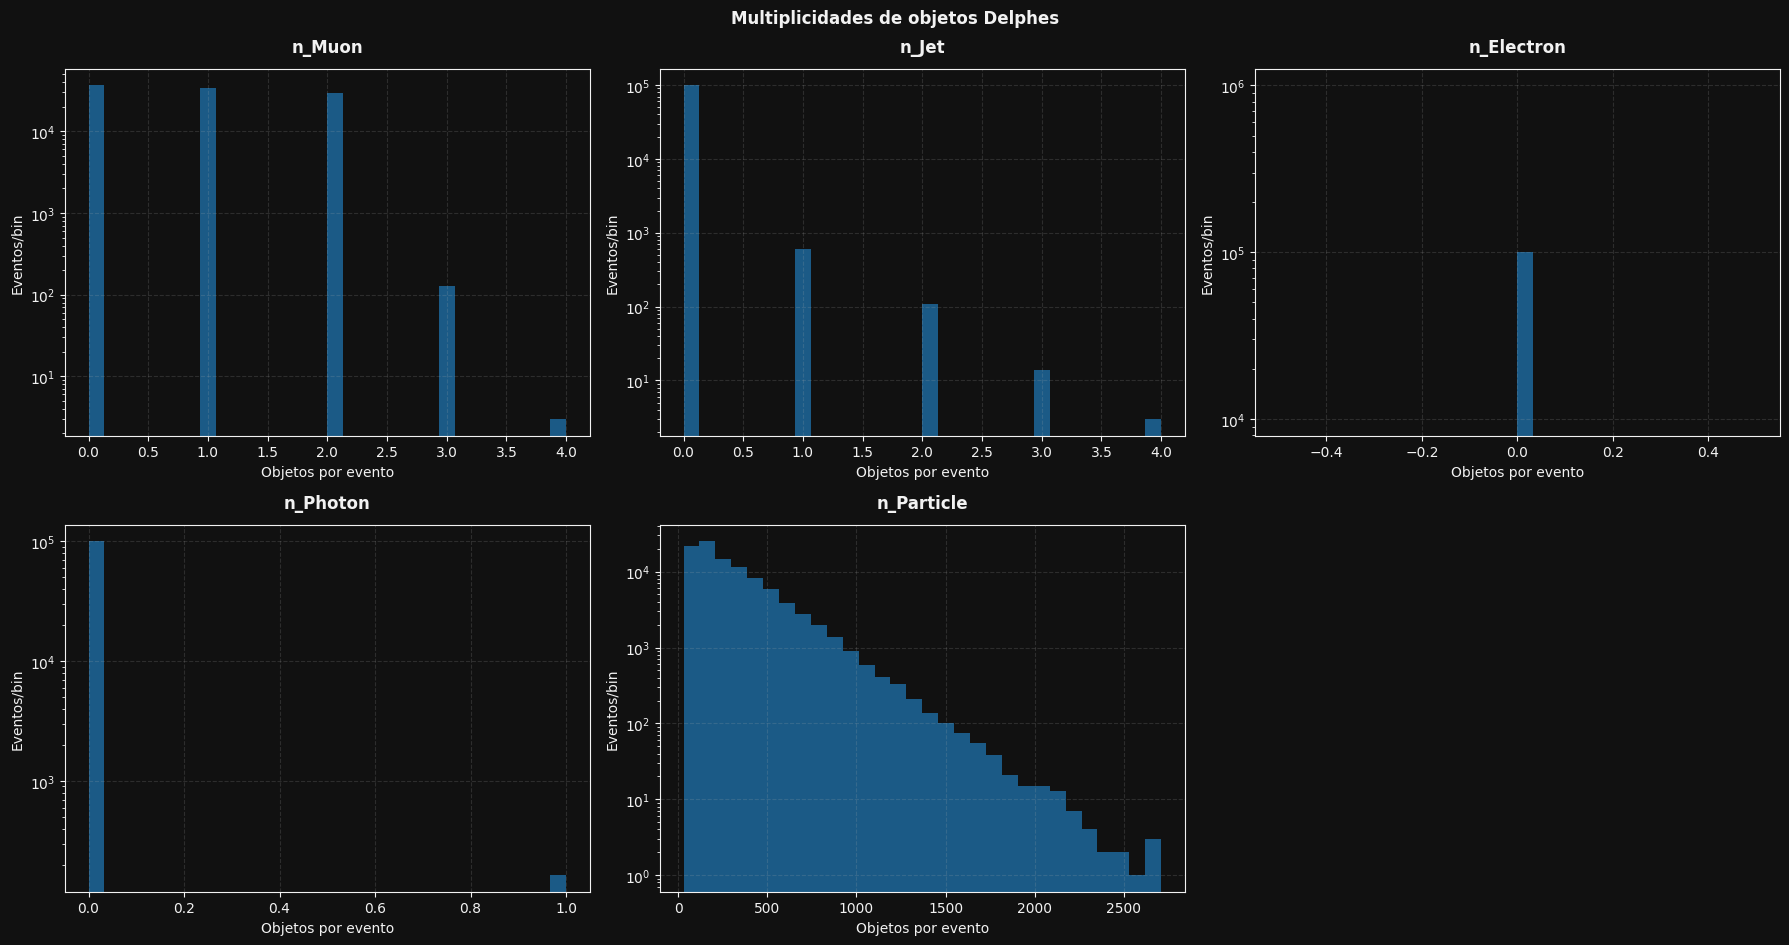

(<Figure size 1800x960 with 6 Axes>,
 array([[<Axes: title={'center': 'n_Muon'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Jet'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Electron'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>],
        [<Axes: title={'center': 'n_Photon'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Particle'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: >]], dtype=object))

In [ ]:
pt.plot_event_multiplicities(
    df_events, 
    data='delphes02', 
    save=True
)

In [30]:
df_muons = io.load_dataframe(
    branches=None,
    dataset=PDATASET01,
    tree_path='Muons'
)
df_muons.head(7)

Archivo: mpmm_50k_10_pandas.root
Árbol seleccionado: Muons
Total de eventos: 93,127 eventos


,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,IsolationVar,IsolationVarRhoCorr,SumPtCharged,SumPtNeutral,SumPtChargedPU,SumPt,D0,DZ,ErrorD0,ErrorDZ
0,0,0,0,0,267,1.684637,-0.742464,0.080565,5.743815e-09,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0
1,0,1,1,0,332,6.966478,-1.643245,-0.534604,1.078437e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.000000e+00,0.000000e+00,0.0,0.0
2,0,1,1,1,331,0.787320,-1.012069,1.780165,8.912818e-09,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.0,0.0
3,0,2,2,0,142,3.219089,1.229144,0.287179,8.056571e-09,1,...,0.0,0.0,0.0,0.0,0.0,0.0,-1.428808e-13,1.670804e-12,0.0,0.0
4,0,2,2,1,143,2.229985,1.551635,-1.384596,1.082457e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.000000e+00,0.000000e+00,0.0,0.0
5,0,3,3,0,240,1.104897,-1.624396,-1.354811,1.082217e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.000000e+00,0.000000e+00,0.0,0.0
6,0,4,4,0,611,3.531875,-1.360393,-1.390749,9.003996e-09,1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.000000e+00,0.000000e+00,0.0,0.0


In [31]:
cdf_muons = io.load_dataframe(
    branches=None,
    dataset=PDATASET01,
    tree_path='Muons',
    cut=cut
)
cdf_muons.head(7)

Archivo: mpmm_50k_10_pandas.root
Árbol seleccionado: Muons
Total de eventos: 8,769 eventos


,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,IsolationVar,IsolationVarRhoCorr,SumPtCharged,SumPtNeutral,SumPtChargedPU,SumPt,D0,DZ,ErrorD0,ErrorDZ
8,0,7,7,0,165,1.408483,2.357213,2.215427,1.018900e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0,8,8,0,301,5.703640,2.485476,0.679265,1.014677e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0,8,8,1,302,2.803500,2.492610,-0.478320,1.014491e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
12,0,10,10,0,893,2.239161,2.304079,-1.913125,1.020891e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,0,13,13,0,266,2.270413,2.281121,0.245213,1.021849e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,0,21,21,0,178,1.010369,2.277413,0.991628,1.022208e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28,0,27,27,1,215,4.510936,2.177431,1.183280,1.026747e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\muon_kinematics_01.png.


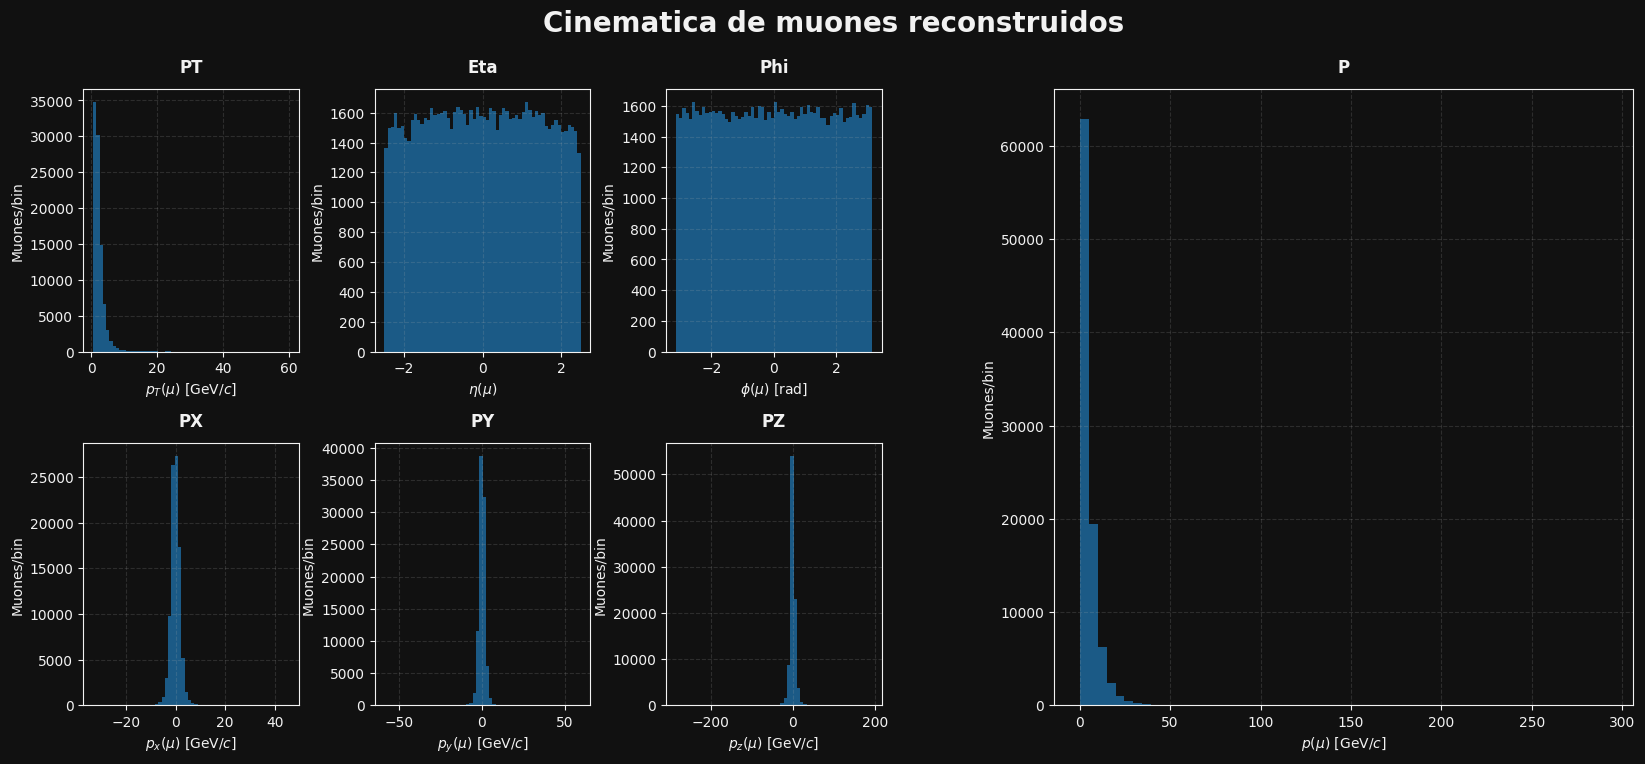

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [ ]:
pt.plot_muon_kinematics(
    df_muons, 
    bins=60, 
    data='delphes02', 
    save=True, 
    filename="muon_kinematics_01"
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\muon_kinematics_01_cut.png.


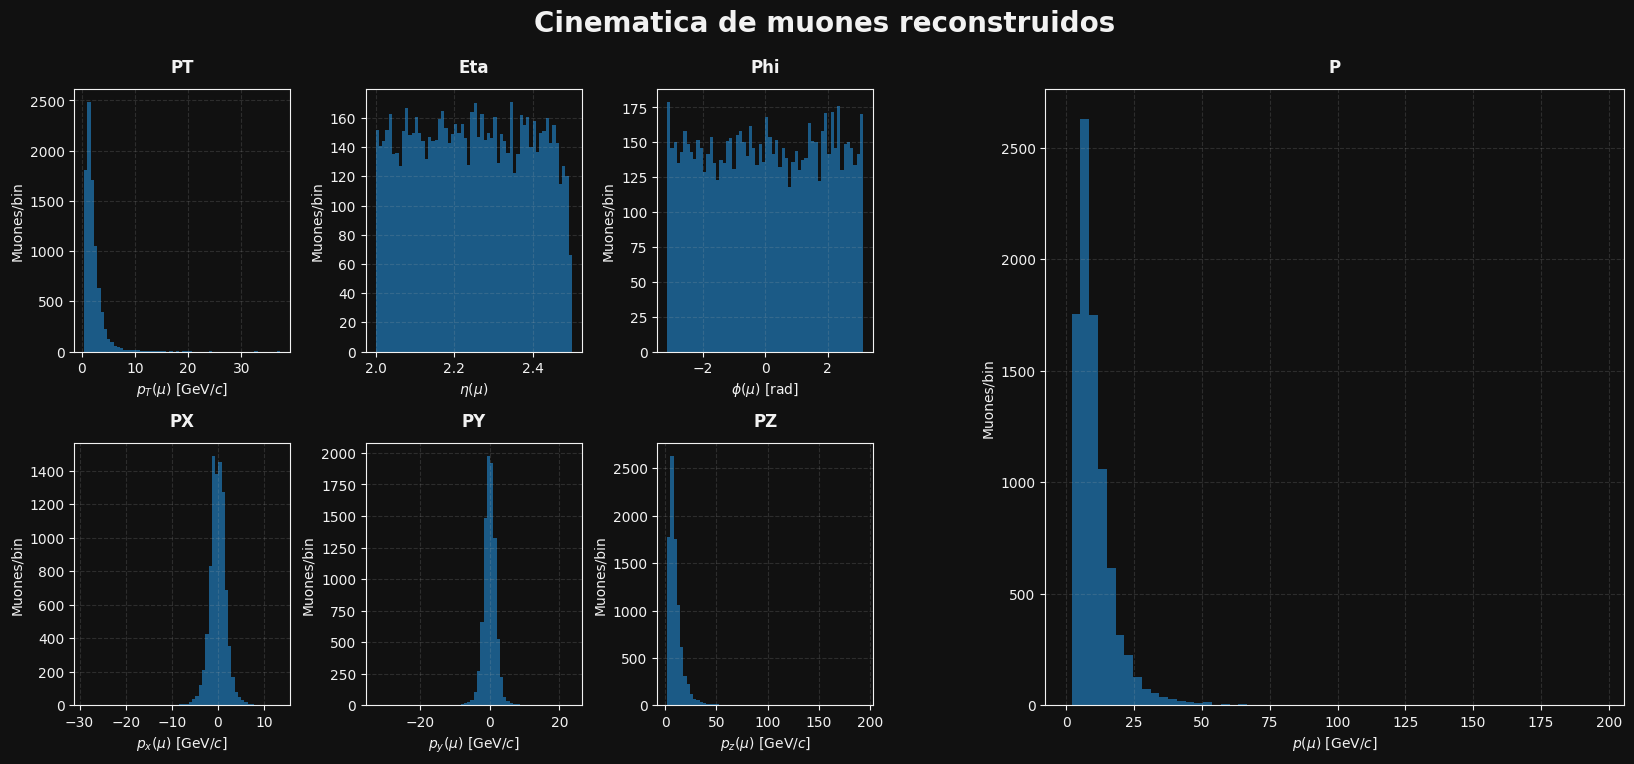

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [ ]:
pt.plot_muon_kinematics(
    cdf_muons, 
    bins=60, 
    data='delphes02', 
    save=True, 
    filename="muon_kinematics_01_cut"
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\muon_kinematics_02.png.


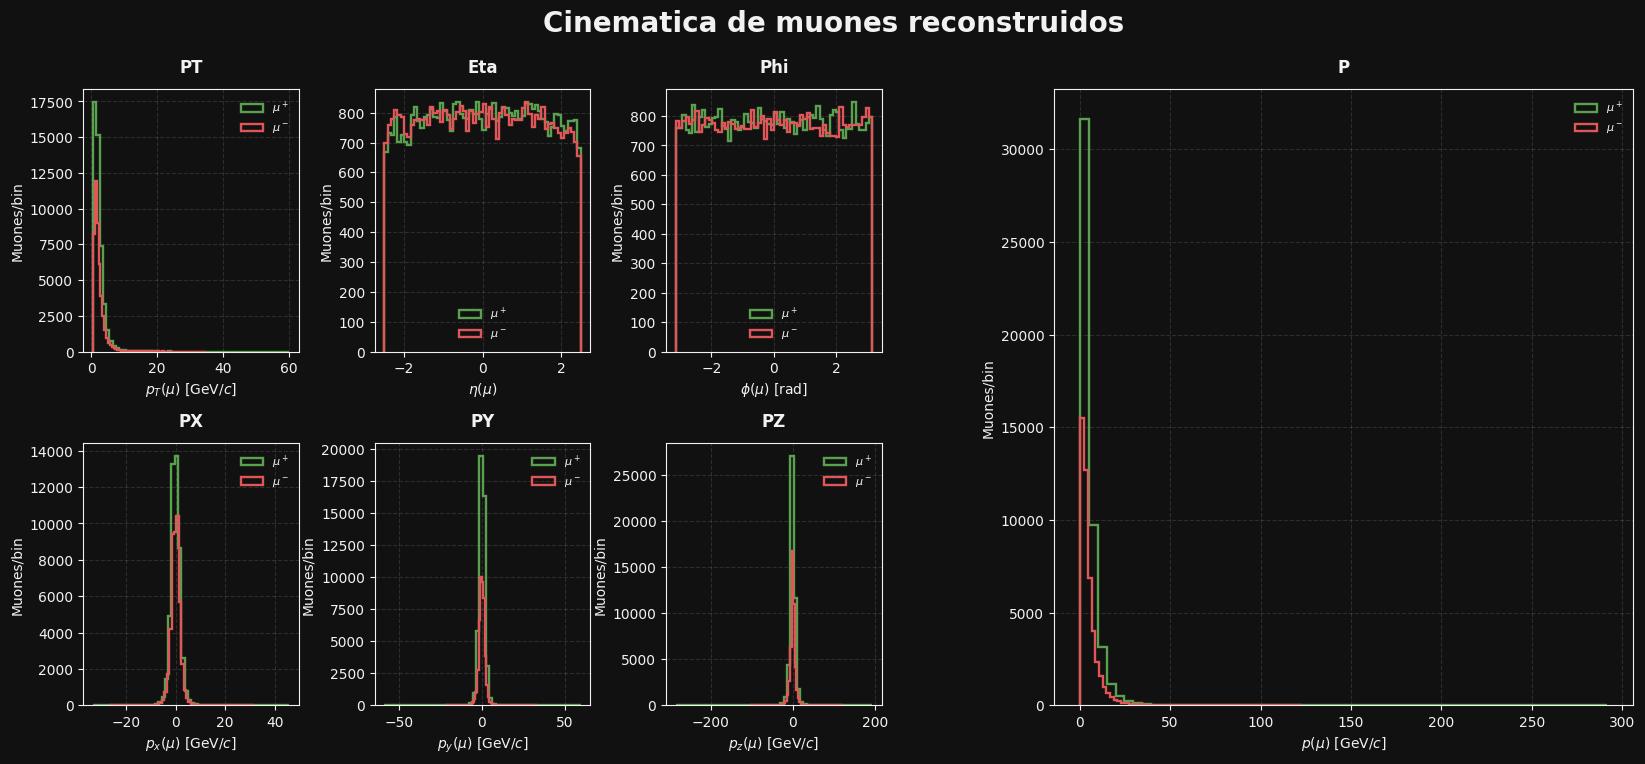

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [ ]:
pt.plot_muon_kinematics(
    df_muons, 
    bins=60, 
    split_charge=True, 
    data='delphes02', 
    save=True, 
    filename="muon_kinematics_02"
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\muon_kinematics_02_cut.png.


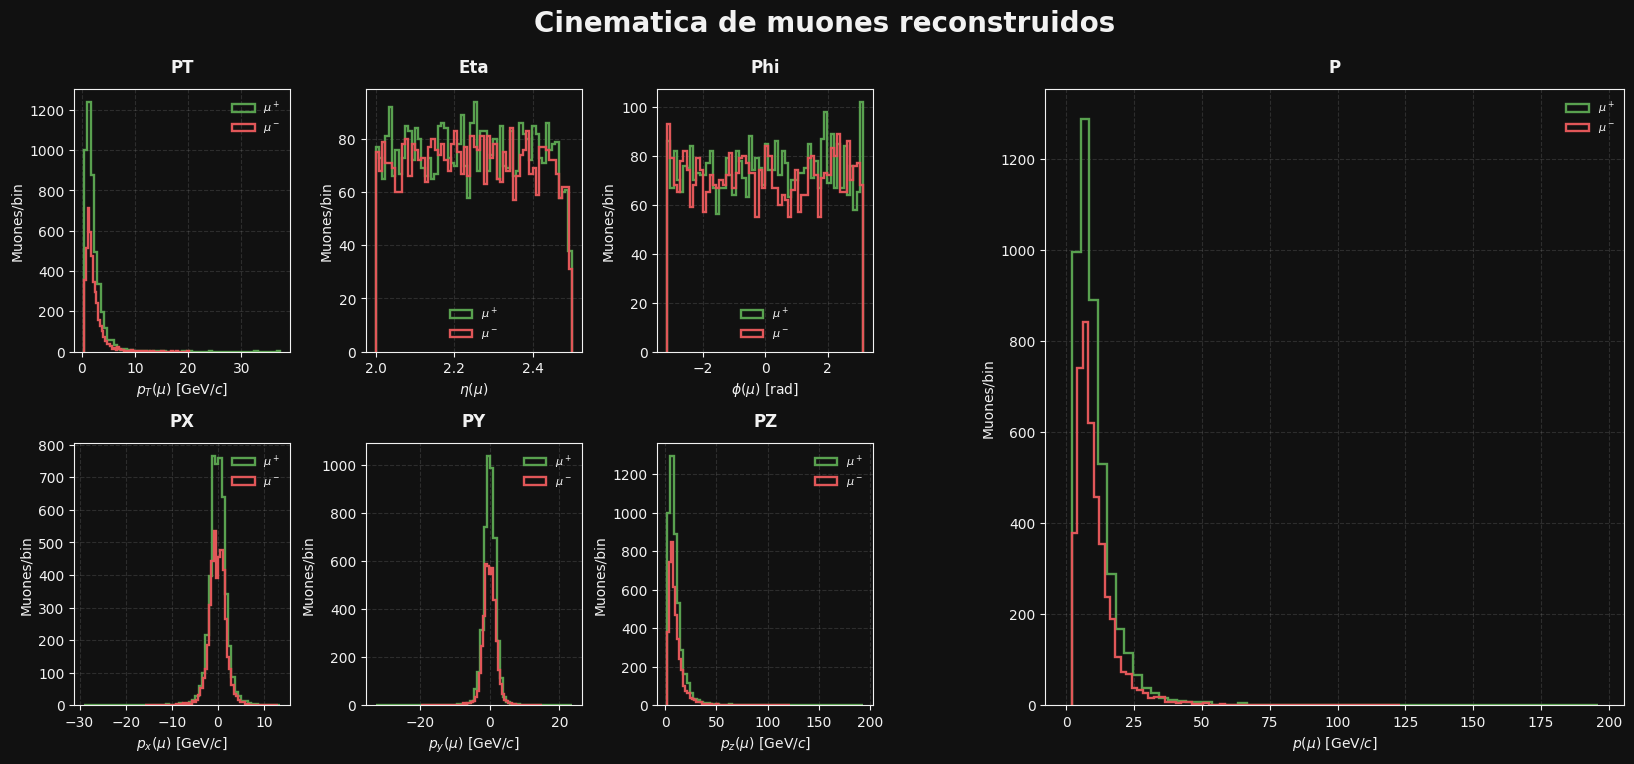

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [ ]:
pt.plot_muon_kinematics(
    cdf_muons, 
    bins=60, 
    split_charge=True, 
    data='delphes02', 
    save=True, 
    filename="muon_kinematics_02_cut"
)

In [38]:
df_muons = ph.calc_four_momentum(df_muons)
df_muons.head()

,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,SumPt,D0,DZ,ErrorD0,ErrorDZ,PX,PY,PZ,P,E
0,0,0,0,0,267,1.684637,-0.742464,0.080565,5.743815e-09,1,...,0.0,0.000000e+00,0.000000e+00,0.0,0.0,1.679173,0.135576,-1.368907,2.170693,2.173263
1,0,1,1,0,332,6.966478,-1.643245,-0.534604,1.078437e-08,-1,...,0.0,-0.000000e+00,0.000000e+00,0.0,0.0,5.994448,-3.549423,-17.341552,18.688532,18.688831
2,0,1,1,1,331,0.787320,-1.012069,1.780165,8.912818e-09,1,...,0.0,0.000000e+00,0.000000e+00,0.0,0.0,-0.163639,0.770127,-0.939990,1.226154,1.230698
3,0,2,2,0,142,3.219089,1.229144,0.287179,8.056571e-09,1,...,0.0,-1.428808e-13,1.670804e-12,0.0,0.0,3.087257,0.911800,5.031051,5.972772,5.973707
4,0,2,2,1,143,2.229985,1.551635,-1.384596,1.082457e-08,-1,...,0.0,-0.000000e+00,0.000000e+00,0.0,0.0,0.412830,-2.191439,5.025581,5.498118,5.499133


In [39]:
cdf_muons = ph.calc_four_momentum(cdf_muons)
cdf_muons.head()

,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,SumPt,D0,DZ,ErrorD0,ErrorDZ,PX,PY,PZ,P,E
8,0,7,7,0,165,1.408483,2.357213,2.215427,1.018900e-08,1,...,0.0,0.0,0.0,0.0,0.0,-0.846362,1.125831,7.371148,7.504509,7.505253
9,0,8,8,0,301,5.703640,2.485476,0.679265,1.014677e-08,1,...,0.0,0.0,0.0,0.0,0.0,4.437631,3.583147,34.003814,34.478847,34.479009
10,0,8,8,1,302,2.803500,2.492610,-0.478320,1.014491e-08,-1,...,0.0,-0.0,0.0,0.0,0.0,2.488862,-1.290418,16.835167,17.066999,17.067326
12,0,10,10,0,893,2.239161,2.304079,-1.913125,1.020891e-08,-1,...,0.0,0.0,0.0,0.0,0.0,-0.751646,-2.109235,11.100750,11.324332,11.324825
13,0,13,13,0,266,2.270413,2.281121,0.245213,1.021849e-08,1,...,0.0,0.0,0.0,0.0,0.0,2.202495,0.551172,10.995016,11.226983,11.227480


In [40]:
df_dimuons = ph.prepare_dimuon_analysis(df_muons, events=df_events)
df_dimuons.head(7)

,event_id,muplus_index,muplus_root_uid,muplus_pt,muplus_eta,muplus_phi,muplus_t,muplus_charge,muplus_particle_ref,muplus_isolation,...,dimuon_charge,dimuon_mass2,muon_sum_pt,pt_balance,acoplanarity,dimuon_rapidity,cos_theta_star,muplus_d0_significance,muminus_d0_significance,displacement_category
0,1,1,331,0.787320,-1.012069,1.780165,8.912818e-09,1,51,0.0,...,0,20.850029,7.753798,0.796920,0.826823,-1.574698,-0.305512,NaN,NaN,mixed
1,2,0,142,3.219089,1.229144,0.287179,8.056571e-09,1,18,0.0,...,0,16.602116,5.449074,0.181518,1.469818,1.360720,0.159862,NaN,NaN,mixed
2,4,0,611,3.531875,-1.360393,-1.390749,9.003996e-09,1,141,0.0,...,0,11.030134,4.900534,0.441425,1.606259,-1.196309,0.279212,NaN,NaN,mixed
3,8,0,301,5.703640,2.485476,0.679265,1.014677e-08,1,44,0.0,...,0,19.189740,8.507140,0.340907,1.984008,2.487484,0.003567,NaN,NaN,mixed
4,13,0,266,2.270413,2.281121,0.245213,1.021849e-08,1,28,0.0,...,0,5.199316,2.941435,0.543745,0.874154,2.212109,-0.140482,NaN,NaN,mixed
5,16,1,263,1.119905,-0.828671,2.767447,6.412160e-09,1,47,0.0,...,0,4.560969,2.382621,0.059939,1.902254,-0.159132,0.561779,NaN,NaN,mixed
6,23,0,465,3.175506,-0.281876,-1.921087,4.517688e-09,1,120,0.0,...,0,5.782226,3.822928,0.661295,2.574047,-0.569222,-0.618291,NaN,NaN,mixed


In [41]:
cdf_dimuons = ph.prepare_dimuon_analysis(cdf_muons, events=df_events)
cdf_dimuons.head(7)

,event_id,muplus_index,muplus_root_uid,muplus_pt,muplus_eta,muplus_phi,muplus_t,muplus_charge,muplus_particle_ref,muplus_isolation,...,dimuon_charge,dimuon_mass2,muon_sum_pt,pt_balance,acoplanarity,dimuon_rapidity,cos_theta_star,muplus_d0_significance,muminus_d0_significance,displacement_category
0,8,0,301,5.703640,2.485476,0.679265,1.014677e-08,1,44,0.0,...,0,19.189740,8.507140,0.340907,1.984008,2.487484,0.003567,NaN,NaN,mixed
1,268,1,302,1.158260,2.174684,2.925771,1.027082e-08,1,52,0.0,...,0,12.225238,9.059525,0.744300,1.921276,2.076964,-0.055663,NaN,NaN,mixed
2,271,0,518,3.443634,2.089244,3.010826,1.031863e-08,1,109,0.0,...,0,11.402998,5.001514,0.377036,1.586381,2.208214,0.188896,NaN,NaN,mixed
3,429,0,154,2.430470,2.209367,-2.744947,1.025149e-08,1,21,0.0,...,0,7.930110,3.230098,0.504890,0.054323,2.265317,0.117094,NaN,NaN,mixed
4,734,1,150,1.062856,2.067174,3.046242,1.033560e-08,1,15,0.0,...,0,4.825274,2.149086,0.010876,0.022882,2.250401,0.183831,NaN,NaN,mixed
5,1056,1,1152,2.742536,2.169446,-1.692663,1.027197e-08,1,281,0.0,...,0,4.564402,5.634852,0.026581,2.418863,2.303817,0.130832,NaN,NaN,mixed
6,1066,0,392,3.746358,2.417284,2.397453,1.016744e-08,1,63,0.0,...,0,32.623755,6.094547,0.229413,0.570459,2.362742,-0.069800,NaN,NaN,mixed


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\dimuon_mass_01.png.


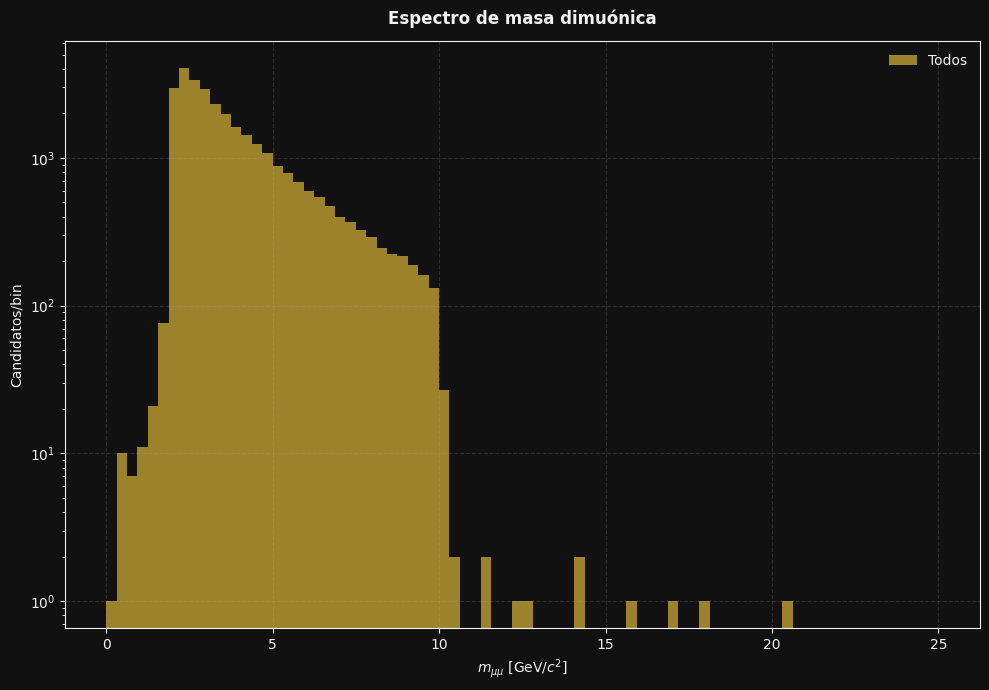

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuónica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [ ]:
pt.plot_dimuon_mass(
    df_dimuons, 
    bins=80,
    mass_range=(0.0, 25.0),
    save=True, 
    log_y=True, 
    data='delphes02', 
    filename="dimuon_mass_01"
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c02\dimuon_mass_01_cut.png.


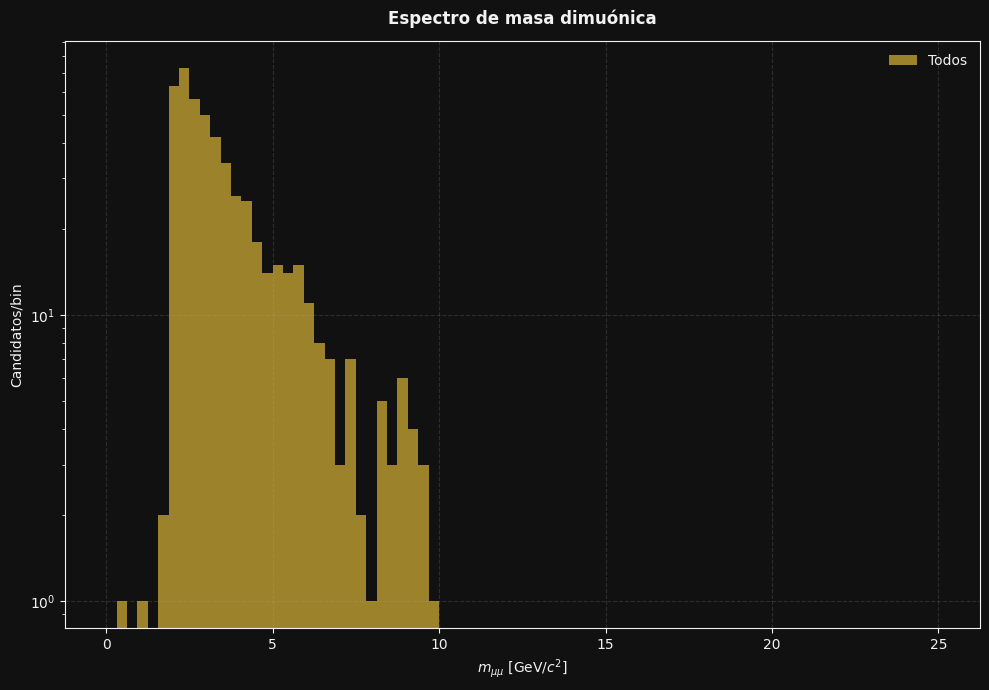

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuónica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [ ]:
pt.plot_dimuon_mass(
    cdf_dimuons, 
    bins=80, 
    mass_range=(0.0, 25.0), 
    save=True, 
    log_y=True, 
    data='delphes02', 
    filename="dimuon_mass_01_cut"
)